In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")

In [2]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.svm import SVR
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [8]:
df=pd.read_csv("StudentsPerformance.csv")

In [9]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
## independent and dependent features
x=df.drop(columns=['math score'])
y=df['math score']

In [10]:
x.head(
    
)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,74
1,female,group C,some college,standard,completed,90,88
2,female,group B,master's degree,standard,none,95,93
3,male,group A,associate's degree,free/reduced,none,57,44
4,male,group C,some college,standard,none,78,75


In [12]:
y.head

<bound method NDFrame.head of 0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64>

In [13]:
num_features=x.select_dtypes(exclude='object').columns
cat_features=x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

num_transformer=StandardScaler()
oh_transformer=OneHotEncoder(drop='first')

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",num_transformer,num_features)
    ]
)

In [14]:
x=preprocessor.fit_transform(x)

In [15]:
x

array([[ 0.        ,  1.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 0.        ,  1.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 0.        ,  0.        ,  1.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 0.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 14))

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((800, 14), (200, 14))

In [17]:
def evaluate(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    r2=r2_score(true,predicted)
    print('mae->',mae,'mse->',mse,'r2_score->',r2)

In [18]:
models={
    "Random Forest":RandomForestRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Logestic regression": LinearRegression(),
    "KNeighborsRegressor" : KNeighborsRegressor(),
    "Adaboost" : AdaBoostRegressor(),
    "Gradient boost": GradientBoostingRegressor(),
    "Lasso":Lasso(),
    "Ridge":Ridge(),
    "XGBRegressor":XGBRegressor(),
    "CatBoostRegressor":CatBoostRegressor(),
    "LinearRegression":LinearRegression()
}
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train)
    
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)
    
    print('--------------------------------------------------------------------------------------------------')
    print('--------------------------------------------------------------------------------------------------')
    print(list(models.keys())[i])
    evaluate(y_train,y_train_pred)
    print('--------------------------------------------------------------------------------------------------')
    evaluate(y_test,y_test_pred)

--------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------
Random Forest
mae-> 1.8369177083333335 mse-> 5.339412370659723 r2_score-> 0.9763163809591563
--------------------------------------------------------------------------------------------------
mae-> 4.679175 mse-> 35.99563354861111 r2_score-> 0.8520758189064648
--------------------------------------------------------------------------------------------------
--------------------------------------------------------------------------------------------------
Decision Tree
mae-> 0.01875 mse-> 0.078125 r2_score-> 0.9996534669718089
--------------------------------------------------------------------------------------------------
mae-> 6.26 mse-> 60.75 r2_score-> 0.7503476639938456
--------------------------------------------------------------------------------------------------
-------------------

In [19]:
lin_model=LinearRegression(fit_intercept=True)
lin_model=lin_model.fit(x_train,y_train)
y_pred=lin_model.predict(x_test)
score=r2_score(y_test,y_pred)*100
print('accuracy of linear model-> ',score)

accuracy of linear model->  88.04332983749565


Text(0, 0.5, 'predicted')

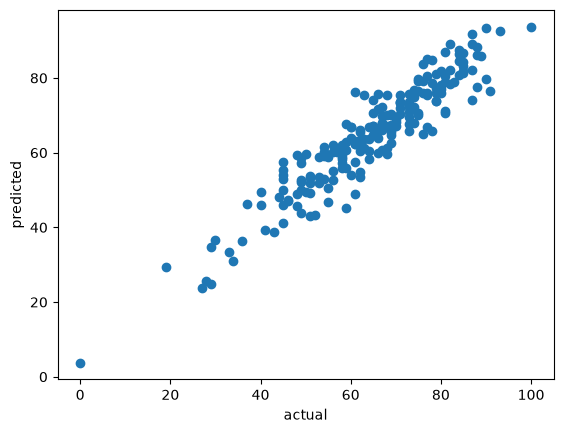

In [20]:
plt.scatter(y_test,y_pred)
plt.xlabel("actual")
plt.ylabel("predicted")

### difference between actual and predicted

In [21]:
df_pred=pd.DataFrame({'actual value':y_test,'predicted value':y_pred,'diffrence':y_test-y_pred})
df_pred

,actual value,predicted value,diffrence
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
...,...,...,...
408,52,43.409149,8.590851
332,62,62.152214,-0.152214
208,74,67.888395,6.111605
613,65,67.022287,-2.022287
